# Astronomy Unsupervised

This example demonstrates a plausible astronomy workflow for identifying anomalous galaxies using image-based,
unsupervised machine learning.

## Overview

A fairly typical machine learning pipeline is used for this example, though it has been streamlined for presentation. The workflow is:

- Acquire an HSC dataset from Zenodo
- Initialize Hyrax
- Train an autoencoder model
- Process data with the trained model
- Calculate similarity with a vector database
- Reduce the dimensionality of results with UMAP
- Plot the latent space

## The data

This example uses roughly 1000 Hyper Suprime-Cam (HSC) cutouts, each 8 arcseconds on a side in `g`, `i`, and `r` bands. These cutouts were acquired previously from the HSC cutout service and then cached in Zenodo for easier access.

## The model

This demonstration uses `HyraxAutoencoderV2`, an example model built into Hyrax. Because this is an unsupervised workflow, the goal is not classification against fixed labels, but learning a compact latent representation that can be used for similarity search and anomaly discovery.

The source code for this model is available on [GitHub](https://github.com/lincc-frameworks/hyrax/blob/main/src/hyrax/models/hyrax_autoencoderv2.py).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Acquire an HSC dataset from Zenodo

We acquired a small sample of HSC cutouts and cached them in Zenodo for convenience.
We'll pull those down now using `pooch`.

In [ ]:
import pooch

file_path = pooch.retrieve(
    # DOI for Example HSC dataset
    url="doi:10.5281/zenodo.14498536/hsc_demo_data.zip",
    known_hash="md5:1be05a6b49505054de441a7262a09671",
    fname="example_hsc_new.zip",
    path="../../data",
    processor=pooch.Unzip(extract_dir="."),
)

## Initialize Hyrax

We begin, as usual, by creating an instance of Hyrax.

In [3]:
from hyrax import Hyrax

h = Hyrax()

With our instance of Hyrax created, we'll edit the configuration.
The configuration system in Hyrax is substantial and comes with reasonable defaults.
We'll make a few changes to specify:
- The model we intend to train
- The number of training epochs
- The training batch size
- The data that we intend to use

In [ ]:
# Specify the location of the data (also referenced later for visualization)
data_dir = "../../data/hsc_8asec_1000"

# Select the model to use for training
h.set_config("model.name", "HyraxAutoencoderV2")

# Set the number of epochs and batch size for training.
h.set_config("train.epochs", 20)
h.set_config("data_loader.batch_size", 32)

data_request_definition = {
    "train": {
        "data": {
            "dataset_class": "HSCDataset",
            "data_location": data_dir,
            "primary_id_field": "object_id",
        },
    },
    "validate": {
        "data": {
            "dataset_class": "HSCDataset",
            "data_location": data_dir,
            "primary_id_field": "object_id",
        },
    },
}
h.set_config("data_request", data_request_definition)
h.set_config("split", {"train": 0.8, "validate": 0.2})

## Train an autoencoder model

With the configuration set correctly, we'll being training our model.

In [ ]:
model = h.train()

The results of training are persisted by default in a timestamped directory and include:
- Full copy of the complete configuration
- The trained model weights
- Checkpoint files
- Training metric records

## Process data with the trained model

Now that we have trained a model, we can use it for inference to produce lower dimensional representations of provided data.
We'll tweak the configuration again before running infrence to:
- Increase the batch size for faster processing
- Specify the data to process (in this case the same data as was used for training, but without splits)

In [ ]:
# Increase batch size for faster inference
h.config["data_loader"]["batch_size"] = 512

# Define the data to use for inference (in this case, the entire dataset)
data_request_definition = {
    "infer": {
        "data": {
            "dataset_class": "HSCDataset",
            "data_location": data_dir,
            "primary_id_field": "object_id",
        },
    },
}
h.set_config("data_request", data_request_definition)

# Run inference
inference_results = h.infer()

The results are placed in a timestamped directory for easy reference.
The result directory will contain:
- The results of inference, in `lance` format
- A complete copy of the configuration used
- A copy of the model weights used to produce the results
- Metrics associated with inference

## Calculate similarity with a vector database

We'll take each of the results of inference and calculate a similarity score.
The `lance` file format readily supports vector database queries, so for each result, we'll find the L2 distances to the 5 nearest neighbors.
To reduce that to a single value per sample, we'll record the median of those 5 distances, and produce a histogram.

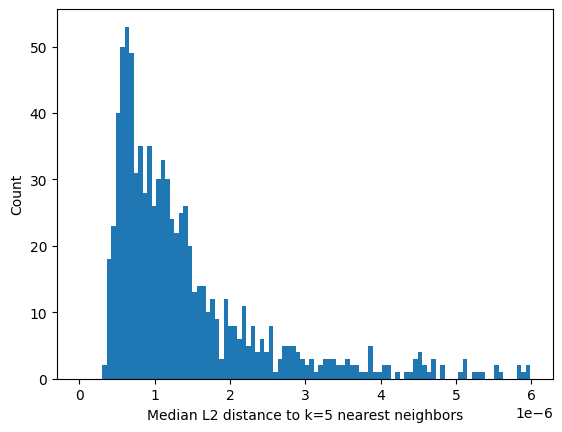

In [7]:
all_embeddings = [inference_results[i].flatten() for i in range(len(inference_results))]
knn_distances = []
for emb in all_embeddings:
    # find the 5 nearest neighbors for this embedding and get their distances
    results = inference_results.table.search(emb).metric("L2").limit(6).to_list()
    dists = [r["_distance"] for r in results[1:]]
    knn_distances.append(dists)

median_dist_all_nn = np.median(knn_distances, axis=1)

# Plot a histogram of the median distances
plt.figure()
plt.hist(median_dist_all_nn, bins=100, range=(0, np.mean(median_dist_all_nn) * 2))
plt.xlabel("Median L2 distance to k=5 nearest neighbors")
plt.ylabel("Count")
plt.show()

> Aside: What is a "vector database"?
>
> A vector database is one which is optimized to store vectors and maintains an index that can be exploited to provide rapid look up of similar vectors.
> The similarity between vectors is defined by the distance between them, where the definition of distance is configurable.
> By default, Hyrax uses squared L2 norm.
> Thus, given a latent space vector for a given object, the database provides an efficient way to find the k most similar vectors.

By making use of the vector database built into Hyrax, we have:
- Efficiently found the L2 norm distance to each of the k=5 nearest neighbors for every vector produced by inference.
- Calculated the median of the distances to the k nearest neighbors.
- Plotted the histogram of those median values.

There appears to be a long tail in the distribution of values, indicating that there are a small number of objects with latent space vectors that have median L2 norm distances much greater than the average.
Let's explore in more detail the objects near the average versus those in the tail.

### Exploring the distribution

Let's take the list of inference results with object ids and sort those according to increasing median distance from its nearest neighbors.

In [8]:
from pathlib import Path
import glob


def sort_objects_by_median_distance(object_ids, median_dist_all_nn, data_directory):
    """Order all the objects according to median distance to nearest neighbor.
    Return a tuple for easy plotting: (object id, original_index, median distance, file name)."""

    # Use the indexes to gather metadata: object ID, rounded median distance, and file name
    data_directory = Path(data_directory).expanduser().resolve()
    objects = []
    for indx in np.argsort(median_dist_all_nn):
        object_id = object_ids[indx]

        found_files = glob.glob(f"{data_directory / object_id}*.fits")
        file_name = found_files[0][:-11]

        objects.append((object_id, int(indx), median_dist_all_nn[indx], file_name))

    return objects


object_ids = list(inference_results.ids())
sorted_objects = sort_objects_by_median_distance(object_ids, median_dist_all_nn, data_directory=data_dir)

Now that we have a list of objects sorted by increasing median distance to nearest neighbor, let's plot a few. 

Plotting code always takes up so much space... my apologies for the next cell.

In [ ]:
from astropy.io import fits
from matplotlib.colors import LogNorm


def plot_grid(data_list):
    """
    Plots an n x 4 grid of matplotlib plots.

    Parameters
    ----------
    data_list : list of tuples
        Each tuple in the list is (object id, rounded median distance to NN, file name)
    """

    num_cols = 4

    num_plots = len(data_list)
    num_rows = (num_plots + num_cols) // num_cols  # Calculate the number of rows needed

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 2.5 * num_rows))

    for i, data in enumerate(data_list):
        row = i // num_cols
        col = i % num_cols
        ax = axes[row, col]
        plotter(ax, data)

    # Hide any unused subplots
    for j in range(num_plots, num_rows * num_cols):
        fig.delaxes(axes.flatten()[j])

    plt.tight_layout()
    plt.show()


def plotter(ax, data_tuple):
    """Plot the R band image for a given object ID.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes to plot the image on
    data_tuple : (int, float, str)
        Each tuple is (object id, rounded median distance to NN, file name)
    """
    # Read the FITS files
    object_id, index, dist, file_name = data_tuple

    fits_file = file_name + "_HSC-R.fits"
    data = fits.getdata(fits_file)

    # Normalize the data
    data = (data - np.min(data)) / (np.max(data) - np.min(data))

    title = f"ID: {object_id}\nMedian dist: {dist:.2e}"

    # Display the image
    ax.imshow(data, origin="lower", norm=LogNorm(), cmap="Greys")
    ax.set_title(title, y=1.0, pad=-30)
    ax.axis("off")  # Hide the axis

First, the 16 objects with the smallest median distance to their nearest neighbors.

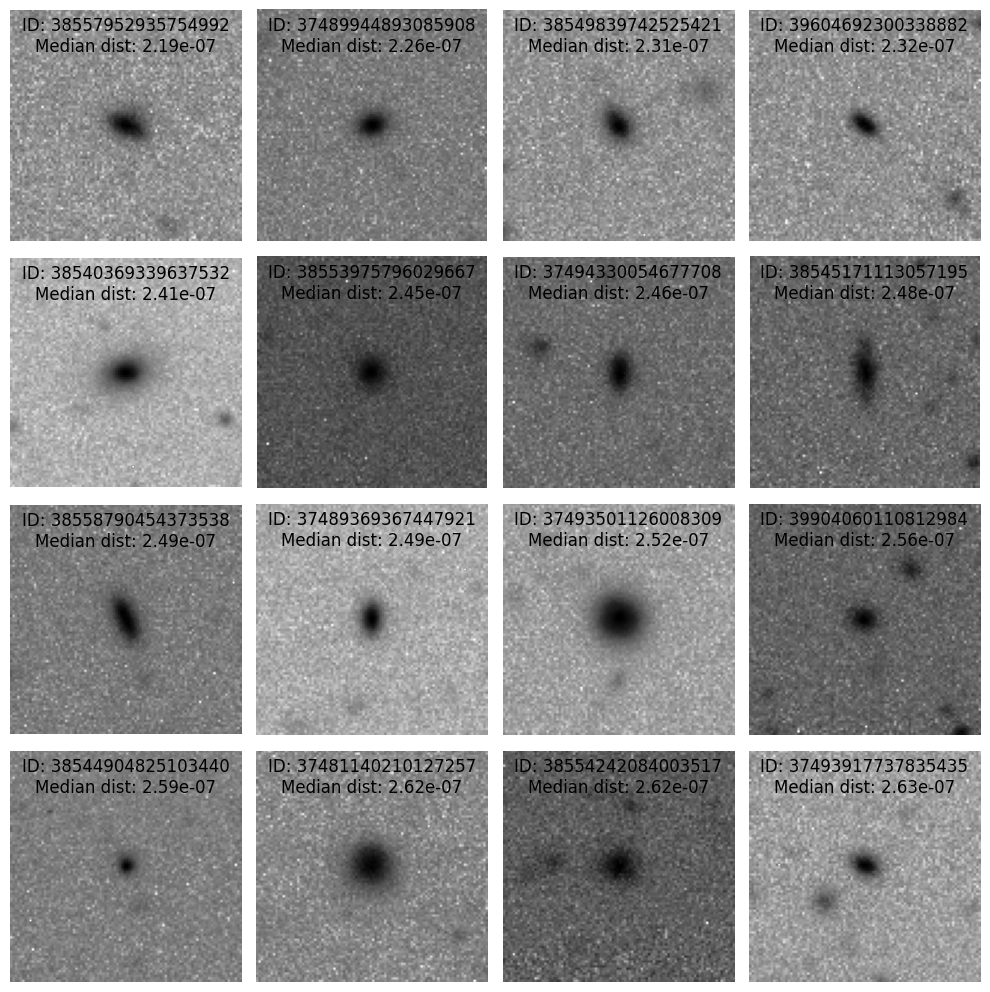

In [10]:
plot_grid(sorted_objects[:16])

Next, the 16 objects with the largest median distance to their nearest neighbors.

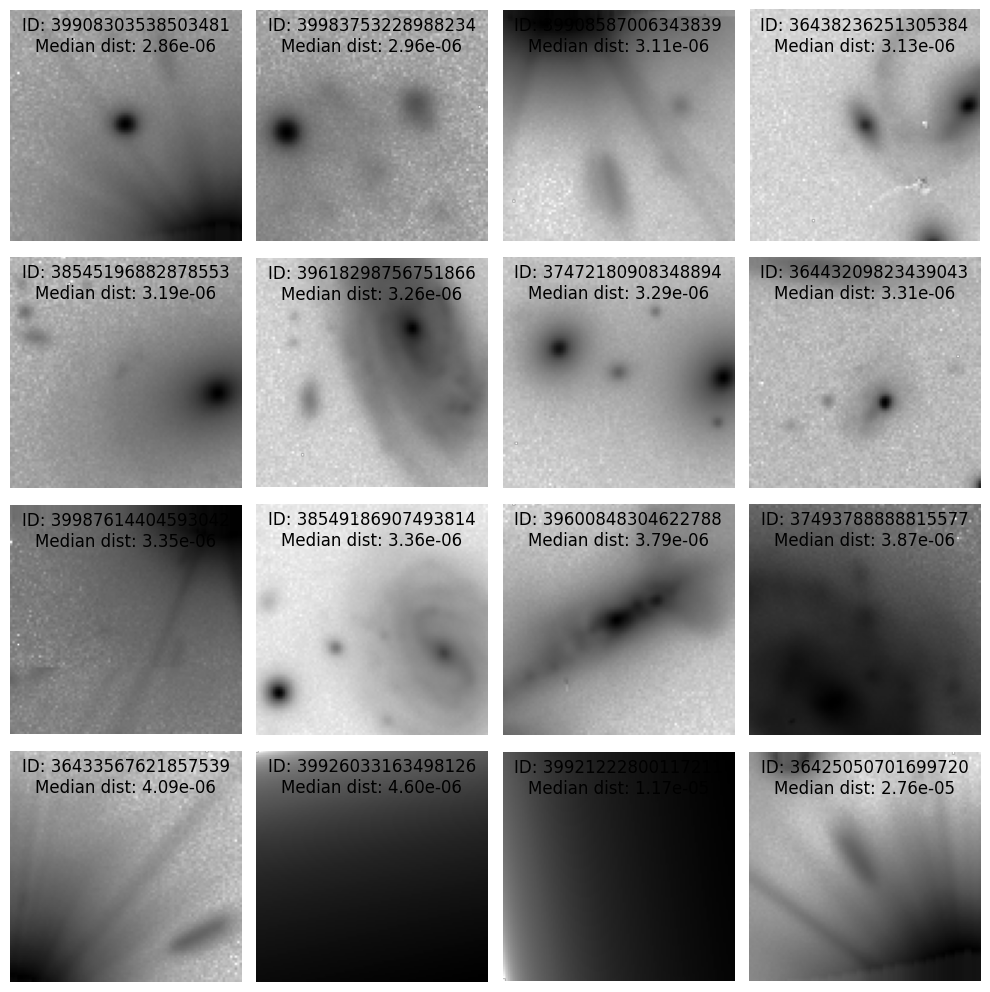

In [11]:
plot_grid(sorted_objects[-16:])

It appears that the objects with small median distance are relatively compact, typically without other nearby objects appearing in the cutout.
The objects with larger median distances tend to be extended, in a crowded space, or contain instrument artifacts.

## Reduce dimensionality of results with UMAP

In order to visualize the latent space, we'll need to reduce the dimensionality.
Techniques like [UMAP](https://umap-learn.readthedocs.io/en/latest/) can help with this.

Here we'll process the 64 dimensional output from the autoencoder through UMAP to reduce the dimensionality to 2 so that we can plot the latent space.

In [ ]:
h.reduce_dimensions(algorithm="umap")

Let's load the results of UMAP'ing so that we can create a 2d scatter plot and overlay the locations of the small and large median distance populations.

In [13]:
from hyrax.config_utils import find_most_recent_results_dir

results_dir = str(find_most_recent_results_dir(h.config, "umap"))
data_request_definition = {
    "analysis": {
        "umap": {
            "dataset_class": "ResultDataset",
            "data_location": results_dir,
            "primary_id_field": "object_id",
        },
    }
}
h.config["data_request"] = data_request_definition
umap_results = h.prepare()

[2026-06-24 17:10:48,523 hyrax.verbs.prepare:INFO] Finished Prepare


Next we'll gather the UMAP outputs for the two groups of objects plotted above.

In [14]:
normal_index = [sorted_objects[i][1] for i in range(16)]
abnormal_index = [sorted_objects[i][1] for i in range(-16, 0)]

In [15]:
normal_umap = [umap_results["analysis"][ni]["umap"]["data"] for ni in normal_index]
abnormal_umap = [umap_results["analysis"][ai]["umap"]["data"] for ai in abnormal_index]

Finally, let's create the scatter plot and include normal and abnormal points.

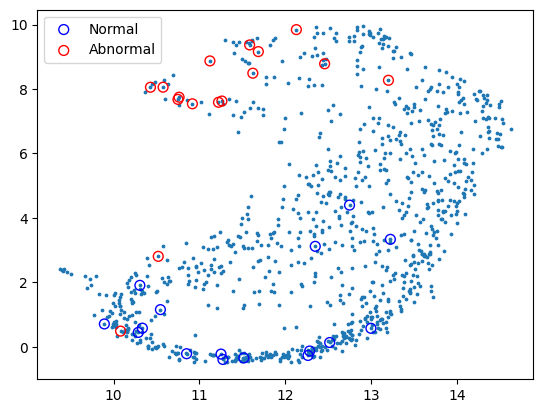

In [16]:
out = np.array([umap_results["analysis"][i]["umap"]["data"] for i in range(len(umap_results["analysis"]))])
fig, ax = plt.subplots()
ax.scatter(out[:, 0], out[:, 1], s=3)
ax.scatter(
    np.array(normal_umap)[:, 0],
    np.array(normal_umap)[:, 1],
    s=50,
    edgecolor="blue",
    facecolor="none",
    label="Normal",
)
ax.scatter(
    np.array(abnormal_umap)[:, 0],
    np.array(abnormal_umap)[:, 1],
    s=50,
    edgecolor="red",
    facecolor="none",
    label="Abnormal",
)
ax.legend()
plt.show()

We can see that there is generally a good separation between the normal (blue) circles and the abnormal (red) circles.

Depending on the specific use case there are variety of extensions to this work:
- Perform clustering to search for additional classes
- Filter out objects that fall in the the instrument artifact region
- Reemit alerts for objects that belong to particular portions of the UMAP space

> **Next-Up:** For a more in-depth unsupervised example, and to see how to use Hyrax's interactive latent-space visualization toolkit and vector database workflows, check the [Extragalactic Unsupervised Discovery](unsupervised_hsc_full_pipeline.ipynb) notebook.